In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import Counter


In [13]:
def generar_espacio_filamentos_test(Ny: int, Nx: int, num_filamentos: int, grosor: int = 4, ruido: bool = True):
    """
    Genera una matriz 2D simulando múltiples filamentos RRAM.
    Los filamentos ocupan TODO el eje X (de columna 0 a Nx-1).
    """
    matriz = np.zeros((Ny, Nx), dtype=int)
    filamentos_ranges = []

    # --- 1. CÁLCULO MATEMÁTICO DE LOS RANGOS EN EL EJE Y ---
    paso = Ny // num_filamentos
    for i in range(num_filamentos):
        fila_min = i * paso
        fila_max = (i + 1) * paso - 1 if i < num_filamentos - 1 else Ny - 1
        filamentos_ranges.append((fila_min, fila_max))

    print(f"Rangos generados para {num_filamentos} filamentos en {Ny} filas: {filamentos_ranges}")

    # --- 2. GENERACIÓN DE LOS FILAMENTOS (Cruzando todo el eje X) ---
    for y_min, y_max in filamentos_ranges:
        # Iniciamos el filamento en el medio de su rango vertical permitido
        y_c = (y_min + y_max) // 2

        # Recorremos TODAS las columnas (Eje X completo)
        for x in range(Nx):
            if ruido:
                # El filamento "baila" aleatoriamente una fila arriba o abajo
                y_c += np.random.choice([-1, 0, 1])
                # Limitamos para que el centro no se salga de su rango asignado
                y_c = max(y_min + grosor, min(y_max - grosor, y_c))

            # Dibujamos el grosor en el eje Y (filas) para esta columna X
            y_inicio = max(y_min, y_c - grosor)
            y_fin = min(y_max, y_c + grosor)

            # Marcamos con 1 las celdas correspondientes
            matriz[y_inicio : y_fin + 1, x] = 1

    return matriz, filamentos_ranges


In [14]:
def obtener_centro_CF(types_map: np.ndarray, cf_ranges: list) -> list:
    """
    Calcula los centros de los filamentos identificando bloques contiguos en cada columna,
    y obteniendo la coordenada (fila) central que más se repite a lo largo de cada rango definido.

    Argumentos:
    - types_map: Matriz 2D del sistema donde 1 indica filamento y 0 vacío.
    - cf_ranges: (OBLIGATORIO) Lista de tuplas indicando el límite físico de cada filamento en el eje Y.
                 Ejemplo para 1 filamento: [(0, 99)].
                 Ejemplo para 2 filamentos: [(0, 49), (50, 99)].

    Retorna:
    - Una lista con los centros (números enteros de fila). Devuelve un centro exacto por cada rango.
    """
    Ny, Nx = types_map.shape
    todos_los_centros = []

    # Recorremos columnas (evitando electrodos 0 y Nx-1)
    for j in range(1, Nx - 1):
        column_data = types_map[:, j]

        # Encontramos los índices (filas) donde hay filamento en esta columna
        fil_indices = np.where(column_data == 1)[0]

        if len(fil_indices) == 0:
            continue

        # --- 1. ALGORITMO DE AGRUPACIÓN (CLUSTERING) ---
        clusters = []
        current_group = [fil_indices[0]]

        for i in range(1, len(fil_indices)):
            # Si el índice actual es consecutivo al anterior, pertenece al mismo bloque
            if fil_indices[i] == fil_indices[i - 1] + 1:
                current_group.append(fil_indices[i])
            else:
                # Se rompió la continuidad: guardamos el bloque y empezamos uno nuevo
                clusters.append(current_group)
                current_group = [fil_indices[i]]
        clusters.append(current_group)  # Guardar el último bloque

        # --- 2. CÁLCULO DEL CENTRO LOCAL DE CADA CLUSTER ---
        for cluster in clusters:
            # Calculamos la media aritmética de los índices (Ej: [18,19,20] -> 19.0)
            media = np.mean(cluster)

            # Redondeamos al entero más cercano y forzamos a que sea tipo 'int'
            centro_entero = int(np.round(media))

            # Guardamos el centro en la lista global del sistema
            todos_los_centros.append(centro_entero)

    # Si la matriz estaba vacía o no había filamentos en el interior
    if not todos_los_centros:
        return [None] * len(cf_ranges)

    # --- 3. OBTENER EL/LOS CENTROS MÁS REPETIDOS SEGÚN LOS RANGOS ---
    centros_por_filamento = []

    for fila_min, fila_max in cf_ranges:
        # Filtramos solo los centros que caen estrictamente dentro de este filamento físico
        centros_en_rango = [c for c in todos_los_centros if fila_min <= c <= fila_max]

        if centros_en_rango:
            # Obtenemos el que MAS se repite en esta región
            centro_ganador = Counter(centros_en_rango).most_common(1)[0][0]
            centros_por_filamento.append(centro_ganador)
        else:
            # Si un rango no tiene filamento formado, devolvemos None
            centros_por_filamento.append(None)

    return centros_por_filamento


In [15]:
def calcular_filas_intermedias(centros: list) -> list:
    """
    Calcula la fila central (punto medio) entre los centros de filamentos consecutivos.

    Argumentos:
    - centros: Lista de enteros con los centros de cada filamento (Ej: [20, 50, 80]).

    Retorna:
    - Una lista de enteros con las filas intermedias (Ej: [35, 65]).
    """
    filas_medias = []

    # Si hay menos de 2 filamentos, no hay distancia intermedia que calcular
    if not centros or len(centros) < 2:
        return filas_medias

    # Recorremos la lista emparejando el elemento actual con el siguiente
    for i in range(len(centros) - 1):
        centro_actual = centros[i]
        centro_siguiente = centros[i + 1]

        # En caso de que un filamento no se haya formado (None), no podemos calcular el medio
        if centro_actual is None or centro_siguiente is None:
            continue

        # Calculamos la media aritmética entre ambos centros
        medio = (centro_actual + centro_siguiente) / 2.0

        # Redondeamos al entero más cercano (fila de la matriz)
        fila_media = int(np.round(medio))
        filas_medias.append(fila_media)

    return filas_medias


Rangos generados para 2 filamentos en 40 filas: [(0, 19), (20, 39)]
Centros calculados para los rangos [(0, 19), (20, 39)]: [14, 32]
[23]


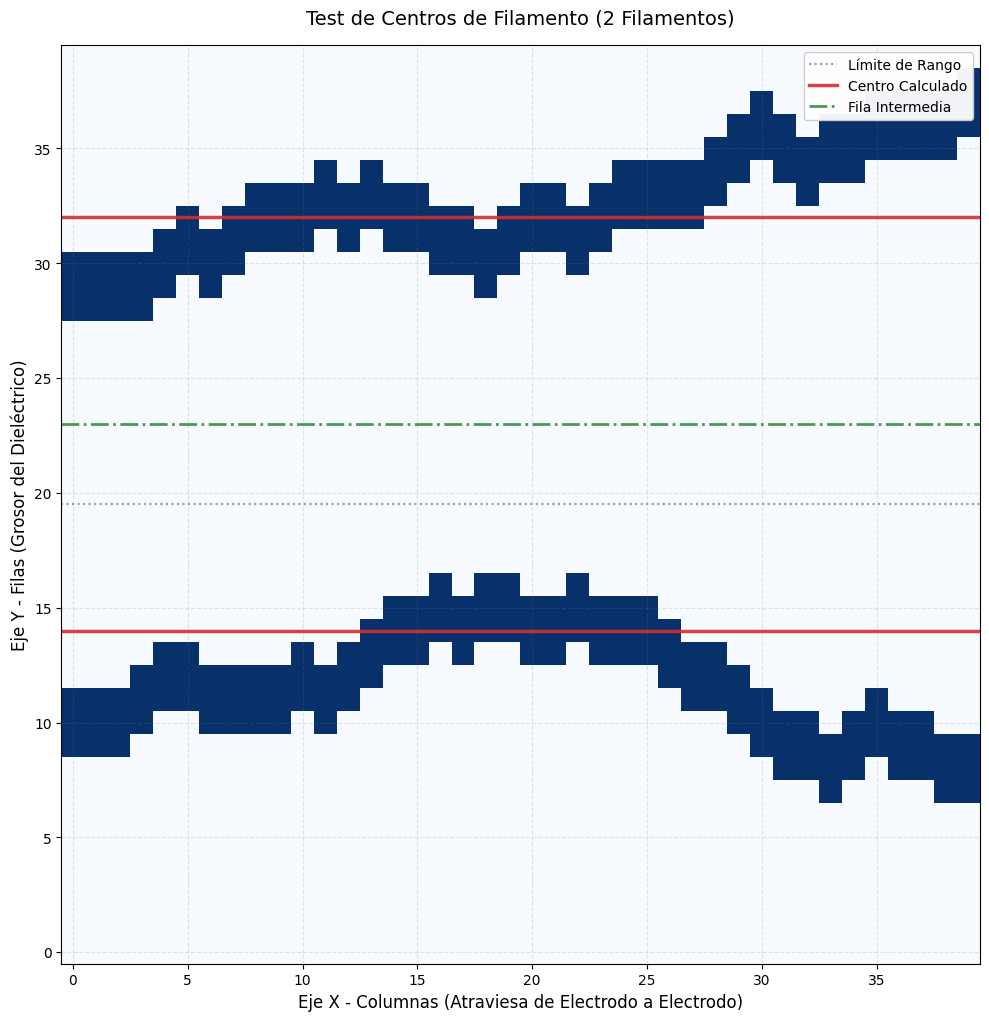

Rangos evaluados: [(0, 19), (20, 39)]
Centros calculados por la función: [14, 32]


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generamos el espacio de prueba (Ej: 100 filas, 100 columnas, 3 filamentos)
Ny, Nx = 40, 40
matriz_test, rangos_test = generar_espacio_filamentos_test(Ny=Ny, Nx=Nx, num_filamentos=2, grosor=1, ruido=True)

# 2. Calculamos los centros con tu función matemática
centros_calculados = obtener_centro_CF(matriz_test, cf_ranges=rangos_test)
print(f"Centros calculados para los rangos {rangos_test}: {centros_calculados}")

filas_intermedias = calcular_filas_intermedias(centros_calculados)

print(filas_intermedias)

# 3. CREAMOS EL PLOT
fig, ax = plt.subplots(figsize=(10, 12))

# origin="lower" asegura que la fila 0 esté abajo y la 99 arriba
cax = ax.imshow(matriz_test, cmap="Blues", origin="lower", aspect="equal")

# Configuramos títulos y etiquetas
ax.set_title(f"Test de Centros de Filamento ({len(rangos_test)} Filamentos)", pad=15, fontsize=14)
ax.set_xlabel("Eje X - Columnas (Atraviesa de Electrodo a Electrodo)", fontsize=12)
ax.set_ylabel("Eje Y - Filas (Grosor del Dieléctrico)", fontsize=12)

# 4. Dibujamos los límites de los rangos (Líneas grises punteadas)
for idx, (ymin, ymax) in enumerate(rangos_test):
    # La línea límite entre filamentos
    if idx < len(rangos_test) - 1:
        ax.axhline(
            y=ymax + 0.5,
            color="gray",
            linestyle=":",
            alpha=0.8,
            linewidth=1.5,
            label="Límite de Rango" if idx == 0 else "",
        )

# 5. Dibujamos los CENTROS calculados (Líneas gruesas rojas)
for idx, centro in enumerate(centros_calculados):
    if centro is not None:
        ax.axhline(
            y=centro,
            color="#D32F2F",
            linestyle="-",
            alpha=0.9,
            linewidth=2.5,
            label="Centro Calculado" if idx == 0 else "",
        )

# Dentro de tu gráfica (después de plotear las líneas rojas de los centros):
for idx, fila_mid in enumerate(filas_intermedias):
    plt.axhline(
        y=fila_mid,
        color="#388E3C",
        linestyle="-.",
        alpha=0.9,
        linewidth=2,
        label="Fila Intermedia" if idx == 0 else "",
    )

# Ajustes visuales (Grid y Leyenda)
ax.grid(color="gray", linestyle="--", alpha=0.2)
ax.legend(loc="upper right", framealpha=0.95)

plt.tight_layout()
plt.show()

# Imprimimos los resultados por consola para verificar
print(f"Rangos evaluados: {rangos_test}")
print(f"Centros calculados por la función: {centros_calculados}")